# End-to-End MRI Pipeline — Runnable

Run each cell top-to-bottom to execute the full pipeline:

1. **Skull stripping** — raw `.nii` → `_brain.nii.gz` via FSL `bet`
2. **Slice extraction** — 3-D volume → 2-D axial PNGs
3. **Dataset loading** — PNGs → labelled PyTorch tensors
4. **Model training** — BrainCNN over 10 epochs
5. **Visualisations** — loss, accuracy, confusion matrix, Grad-CAM

## Stage 1 — Skull Stripping

In [1]:
import sys
sys.path.insert(0, '.')

from preprocessing.fsl_preprocessing import preprocess_folder

RAW       = 'data/raw'
PROCESSED = 'data/processed'

print('=== Stage 1: Skull Stripping ===')
preprocess_folder(RAW, PROCESSED)
print('Done.')

=== Stage 1: Skull Stripping ===
Skipping sub-73_T1w.nii — already processed
Skipping sub-01_T1w.nii — already processed
Skipping sub-02_T1w.nii — already processed
Skipping sub-03_T1w.nii — already processed
Skipping sub-74_T1w.nii — already processed
Skipping sub-75_T1w.nii — already processed
Skipping sub-77_T1w.nii — already processed
Skipping sub-05_T1w.nii — already processed
Skipping sub-76_T1w.nii — already processed
Skipping sub-04_T1w.nii — already processed
Done.


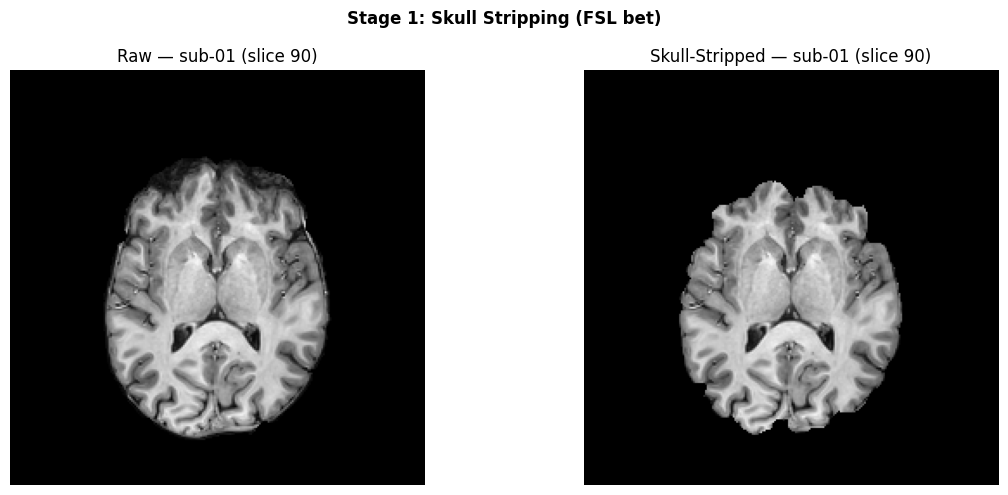

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt

raw  = nib.load('data/raw/sub-01_T1w.nii').get_fdata()
proc = nib.load('data/processed/sub-01_T1w_brain.nii.gz').get_fdata()

mid = raw.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw[:, :, mid].T,  cmap='gray', origin='lower')
axes[0].set_title(f'Raw — sub-01 (slice {mid})')
axes[0].axis('off')

axes[1].imshow(proc[:, :, mid].T, cmap='gray', origin='lower')
axes[1].set_title(f'Skull-Stripped — sub-01 (slice {mid})')
axes[1].axis('off')

plt.suptitle('Stage 1: Skull Stripping (FSL bet)', fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 2 — Slice Extraction

In [3]:
import os
from preprocessing.slice_extraction import extract_slices

SLICES = 'data/slices'

print('=== Stage 2: Slice Extraction ===')
for filename in sorted(os.listdir(PROCESSED)):
    if filename.endswith('.nii.gz'):
        subject       = filename.replace('_brain.nii.gz', '')
        nifti_path    = os.path.join(PROCESSED, filename)
        output_folder = os.path.join(SLICES, subject)
        extract_slices(nifti_path, output_folder)
print('Done.')

=== Stage 2: Slice Extraction ===
Saved 126 slices → data/slices/sub-01_T1w
Saved 131 slices → data/slices/sub-02_T1w
Saved 135 slices → data/slices/sub-03_T1w
Saved 125 slices → data/slices/sub-04_T1w
Saved 122 slices → data/slices/sub-05_T1w
Saved 121 slices → data/slices/sub-73_T1w
Saved 129 slices → data/slices/sub-74_T1w
Saved 132 slices → data/slices/sub-75_T1w
Saved 124 slices → data/slices/sub-76_T1w
Saved 132 slices → data/slices/sub-77_T1w
Done.


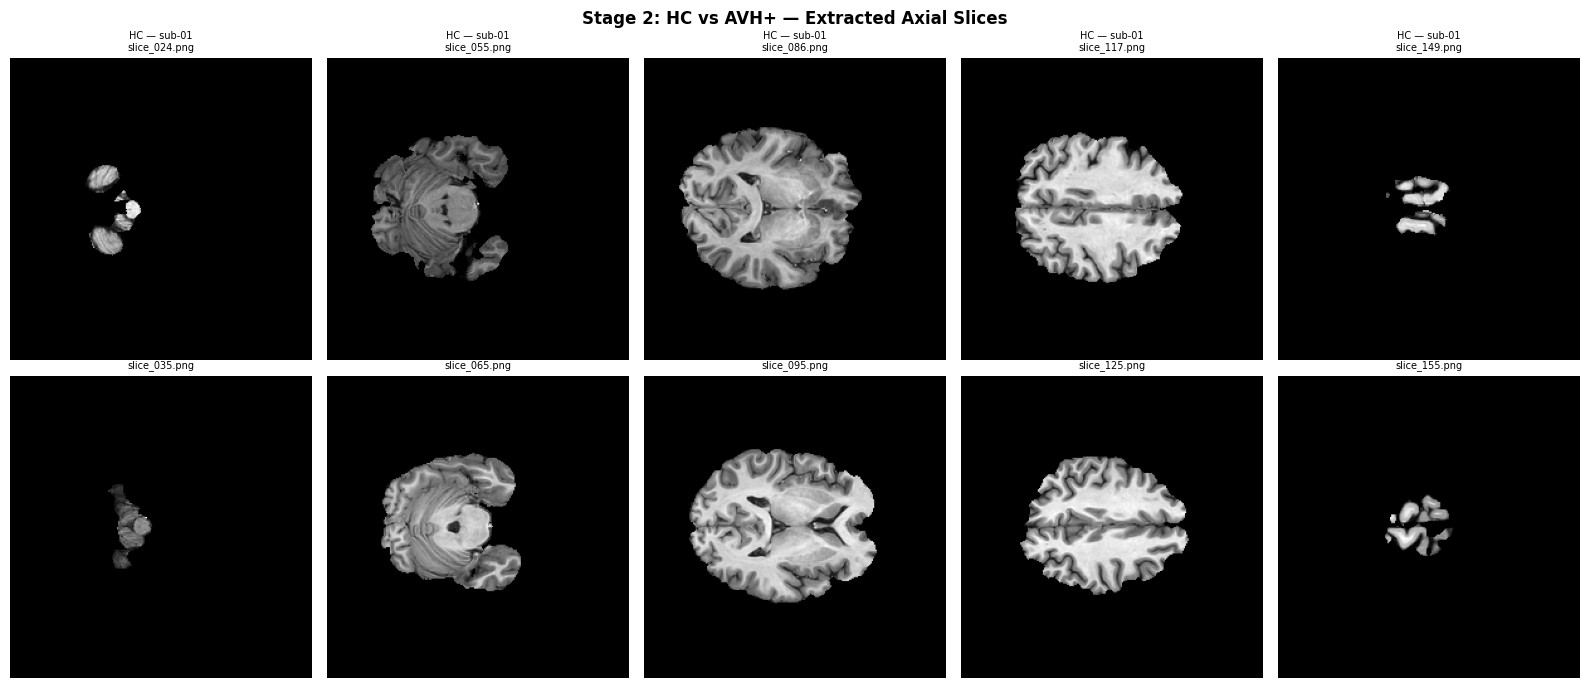

In [4]:
import numpy as np
from PIL import Image

hc_dir  = os.path.join(SLICES, 'sub-01_T1w')
avh_dir = os.path.join(SLICES, 'sub-73_T1w')

hc_files  = sorted(f for f in os.listdir(hc_dir)  if f.endswith('.png'))
avh_files = sorted(f for f in os.listdir(avh_dir) if f.endswith('.png'))

hc_pick  = [hc_files[i]  for i in np.linspace(0, len(hc_files)  - 1, 5, dtype=int)]
avh_pick = [avh_files[i] for i in np.linspace(0, len(avh_files) - 1, 5, dtype=int)]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for col, (hf, af) in enumerate(zip(hc_pick, avh_pick)):
    for row, (d, f, lbl) in enumerate([(hc_dir, hf, 'HC — sub-01'), (avh_dir, af, 'AVH+ — sub-73')]):
        img = Image.open(os.path.join(d, f))
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(f'{lbl}\n{f}', fontsize=7)
        axes[row][col].axis('off')

plt.suptitle('Stage 2: HC vs AVH+ — Extracted Axial Slices', fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 3 — Dataset Loading

In [5]:
from preprocessing.dataset import BrainSliceDataset

TSV = 'data/participants.tsv'

dataset = BrainSliceDataset(SLICES, TSV)
img, label = dataset[0]

print(f'Total samples : {len(dataset)}')
print(f'Tensor shape  : {tuple(img.shape)}  (C x H x W)')
print(f'Pixel range   : [{img.min():.3f}, {img.max():.3f}]')
print(f'Label         : {label}  (0=HC, 1=AVH+)')

all_labels = [dataset[i][1] for i in range(len(dataset))]
print(f'Class balance : HC={all_labels.count(0)}, AVH+={all_labels.count(1)}')

Dataset ready: 1277 slices
Total samples : 1277
Tensor shape  : (1, 128, 128)  (C x H x W)
Pixel range   : [0.000, 0.569]
Label         : 1  (0=HC, 1=AVH+)
Class balance : HC=639, AVH+=638


## Stage 4 — Model Training

In [6]:
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from models.cnn import BrainCNN

EPOCHS        = 10
BATCH_SIZE    = 32
LEARNING_RATE = 0.001

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE)

model     = BrainCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'loss': [], 'val_accuracy': [], 'val_labels': [], 'val_preds': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs      = model(images)
            _, predicted = torch.max(outputs, 1)
            correct     += (predicted == labels).sum().item()
            total       += labels.size(0)
            all_preds.extend(predicted.tolist())
            all_labels.extend(labels.tolist())

    acc = 100 * correct / total
    history['loss'].append(total_loss)
    history['val_accuracy'].append(acc)
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Loss: {total_loss:.4f} | Val Accuracy: {acc:.2f}%')

history['val_labels'] = all_labels
history['val_preds']  = all_preds

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/brain_cnn.pth')
with open('models/history.json', 'w') as f:
    json.dump(history, f)

print('\nModel saved → models/brain_cnn.pth')
print('Metrics saved → models/history.json')

Epoch  1/10 | Loss: 22.2283 | Val Accuracy: 44.53%
Epoch  2/10 | Loss: 21.8294 | Val Accuracy: 60.55%
Epoch  3/10 | Loss: 21.3040 | Val Accuracy: 62.89%
Epoch  4/10 | Loss: 21.0951 | Val Accuracy: 62.89%
Epoch  5/10 | Loss: 20.1259 | Val Accuracy: 66.02%
Epoch  6/10 | Loss: 17.8203 | Val Accuracy: 75.39%
Epoch  7/10 | Loss: 15.8782 | Val Accuracy: 82.03%
Epoch  8/10 | Loss: 13.5252 | Val Accuracy: 83.59%
Epoch  9/10 | Loss: 10.4481 | Val Accuracy: 89.84%
Epoch 10/10 | Loss: 8.5291 | Val Accuracy: 92.58%

Model saved → models/brain_cnn.pth
Metrics saved → models/history.json


## Stage 5 — Visualisations

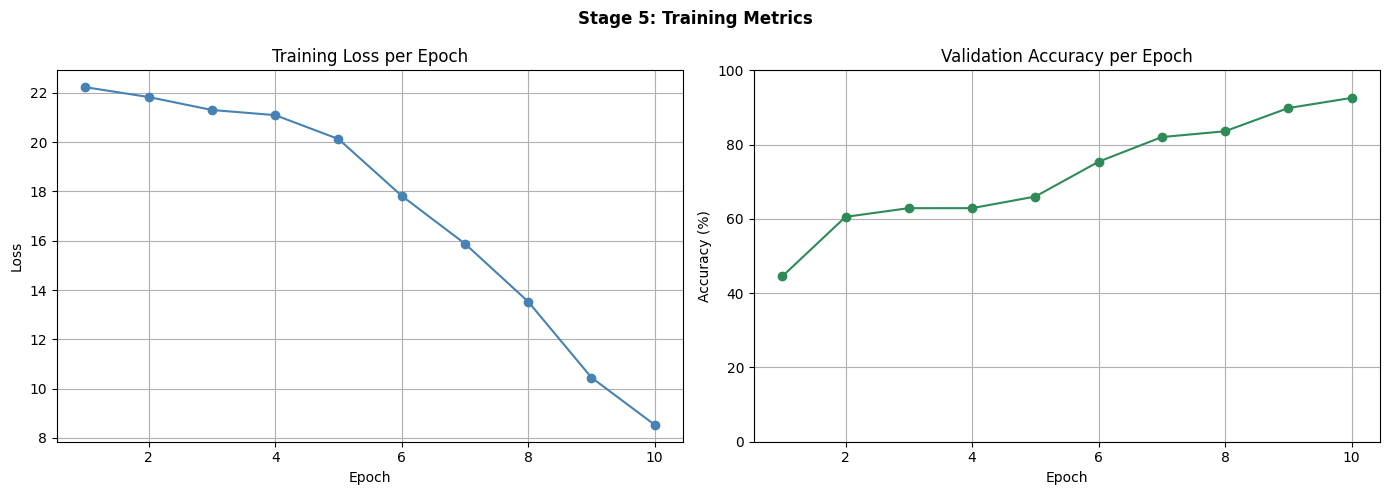

In [7]:
# Loss & accuracy curves
epochs = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history['loss'],         marker='o', color='steelblue')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

axes[1].plot(epochs, history['val_accuracy'], marker='o', color='seagreen')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100); axes[1].grid(True)

plt.suptitle('Stage 5: Training Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

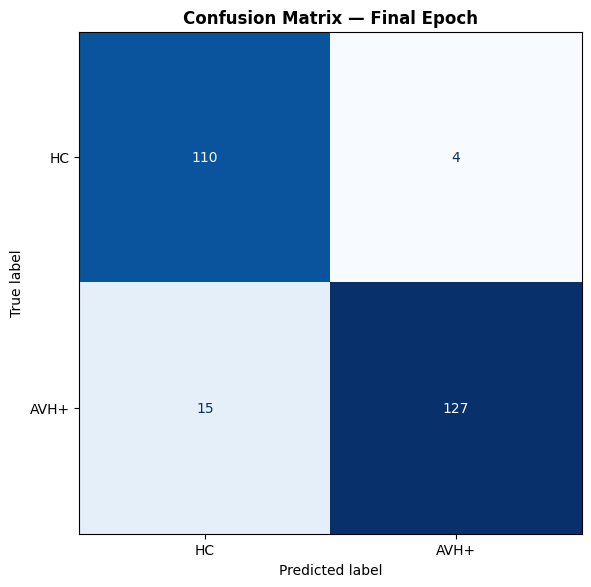

In [8]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(history['val_labels'], history['val_preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC', 'AVH+'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Final Epoch', fontweight='bold')
plt.tight_layout()
plt.show()

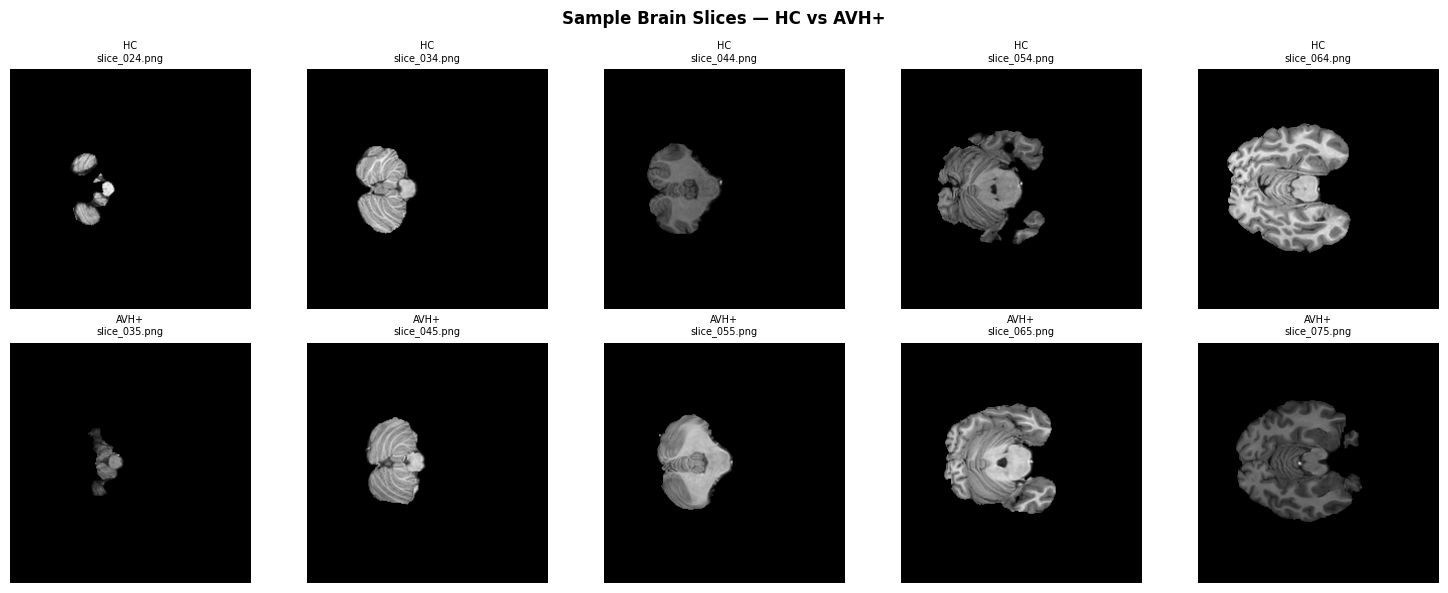

In [9]:
# Sample slices — HC vs AVH+
CLASS_NAMES = ['HC', 'AVH+']
subjects    = [('sub-01_T1w', 'HC'), ('sub-73_T1w', 'AVH+')]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (subject, lbl) in enumerate(subjects):
    folder = os.path.join(SLICES, subject)
    files  = sorted(os.listdir(folder))[::10][:5]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        axes[row][col].set_title(f'{lbl}\n{fname}', fontsize=7)

plt.suptitle('Sample Brain Slices — HC vs AVH+', fontweight='bold')
plt.tight_layout()
plt.show()

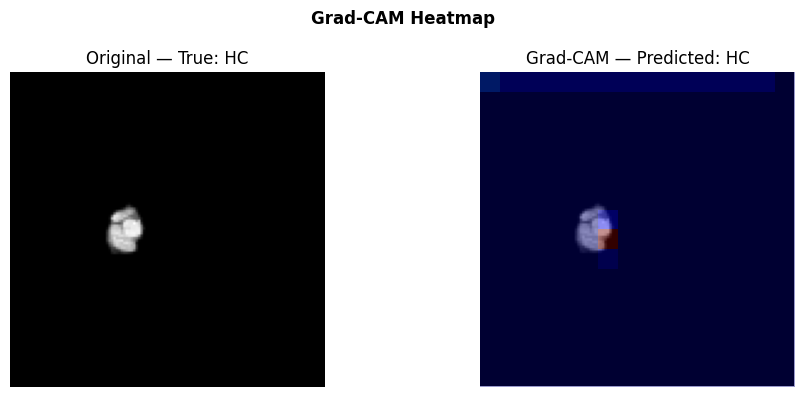

In [10]:
# Grad-CAM
import torch.nn.functional as F

model.eval()

img_tensor, true_label = dataset[len(dataset) // 2]
input_tensor = img_tensor.unsqueeze(0).requires_grad_(True)

features = None
grads    = None

def forward_hook(module, inp, out):
    global features
    features = out

def backward_hook(module, grad_inp, grad_out):
    global grads
    grads = grad_out[0]

handle_f = model.conv[-1].register_forward_hook(forward_hook)
handle_b = model.conv[-1].register_full_backward_hook(backward_hook)

output     = model(input_tensor)
pred_class = output.argmax(dim=1).item()
output[0, pred_class].backward()

handle_f.remove()
handle_b.remove()

weights = grads.mean(dim=(2, 3), keepdim=True)
cam     = (weights * features).sum(dim=1).squeeze()
cam     = F.relu(cam).detach().numpy()
cam     = (cam - cam.min()) / (cam.max() - cam.min())

orig = img_tensor.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig, cmap='gray')
axes[0].set_title(f'Original — True: {CLASS_NAMES[true_label]}')
axes[0].axis('off')

axes[1].imshow(orig, cmap='gray')
axes[1].imshow(cam, cmap='jet', alpha=0.4, extent=[0, orig.shape[1], orig.shape[0], 0])
axes[1].set_title(f'Grad-CAM — Predicted: {CLASS_NAMES[pred_class]}')
axes[1].axis('off')

plt.suptitle('Grad-CAM Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Stage | Input | Output |
|---|---|---|
| 1. Skull stripping | Raw `.nii` files | `_brain.nii.gz` via FSL `bet` |
| 2. Slice extraction | Brain volumes | Axial `.png` slices |
| 3. Dataset loading | PNG slices + `participants.tsv` | Labelled tensors (1×128×128) |
| 4. Training | Tensors, 80/20 split | `brain_cnn.pth` + `history.json` |
| 5. Visualisations | Training history + model | Loss, accuracy, confusion matrix, Grad-CAM |